# Summary Insights: Socioeconomic Determinants of Household Income

This notebook synthesizes findings from the full analysis pipeline:
- **Notebook 02** — Exploratory Data Analysis (EDA)
- **Notebook 03** — Hypothesis Testing (RQ1: Regional Disparities, RQ2: Demographic Associations)
- **Notebook 04** — Regression Modeling (RQ3: Predictive Model)

We present consolidated results, cross-RQ interpretations, policy implications,
and study limitations.

## 1. Executive Summary

Using 41,544 households from the Family Income and Expenditure Survey (FIES), we
identified the strongest socioeconomic determinants of household income in the
Philippines. **Education** is the dominant predictor — it has the largest effect
size in bivariate analysis (η² = 0.289) and the strongest standardized coefficient
in multivariate regression. However, **the education premium varies dramatically
by region**: a college degree in NCR yields a substantially higher return than in
rural agricultural regions (interaction F = 40.78, p ≈ 0). The regression model
explains approximately **50% of income variance** (R² = 0.501), with occupation
type, class of worker, and region as additional key predictors. Family size and
age have small effects once education and occupation are controlled.

## 2. Study Overview

**Dataset:** Family Income and Expenditure Survey (FIES) microdata, Philippines.
- **n = 41,544** households after cleaning
- **63 columns** (income, expenditures, demographics, assets, housing)
- **Outcome variable:** Log Total Household Income (log-transformed to reduce
  skewness from 8.90 to 0.38)

**Research Questions:**
1. **RQ1:** Is there a significant difference in average household income across regions?
2. **RQ2:** To what extent are demographic characteristics associated with income?
3. **RQ3:** Can regional and demographic factors predict income, and which is strongest?

**Analysis Pipeline:**
```
01-data_cleaning → 02-eda → 03-hypothesis_testing → 04-regression_modeling → 05-summary
```

## 3. RQ1: Regional Income Disparities

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data/preprocessed")
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

INCOME_COL = "Log Total Household Income"
ALPHA = 0.05

df = pd.read_csv(DATA_DIR / "preprocessed-fies.csv")
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset: 41,544 rows x 63 columns


### RQ1 Results

All three statistical tests converge on the same conclusion: **reject H₀**. Regional
differences in household income are statistically significant and practically meaningful.

| Test | Statistic | p-value | Conclusion |
|------|-----------|---------|------------|
| One-way ANOVA | F = 388.97 | < 0.001 | Reject H₀ |
| Welch's ANOVA | F = 465.81 | < 0.001 | Reject H₀ |
| Kruskal-Wallis | H = 6021.46 | < 0.001 | Reject H₀ |

**Effect size:** η² = 0.130 — region alone explains ~13% of income variance (medium effect).

**Post-hoc (Tukey HSD):** NCR has the highest mean income, significantly exceeding all
other regions. The NCR–ARMM gap (mean diff = 1.018 log units, ~176% raw income
difference) is the largest pairwise contrast.

### 3.1 Regional Income Distribution

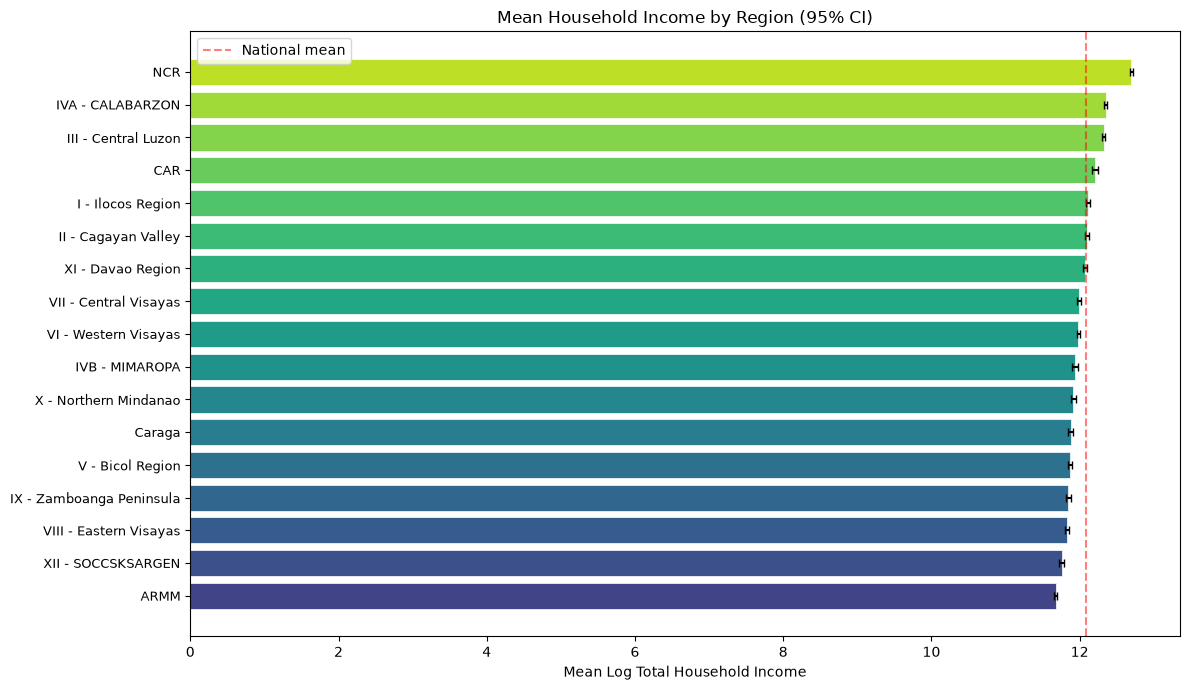

In [2]:
# Regional mean income with 95% CI
region_stats = (
    df.groupby("Region")[INCOME_COL]
    .agg(["mean", "std", "count"])
    .assign(ci95=lambda x: 1.96 * x["std"] / np.sqrt(x["count"]))
    .sort_values("mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = range(len(region_stats))

ax.barh(
    y_pos, region_stats["mean"],
    xerr=region_stats["ci95"],
    color=plt.cm.viridis(np.linspace(0.2, 0.9, len(region_stats))),
    edgecolor="white", linewidth=0.5, capsize=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(region_stats.index, fontsize=9)
ax.set_xlabel("Mean Log Total Household Income")
ax.set_title("Mean Household Income by Region (95% CI)")
ax.axvline(df[INCOME_COL].mean(), color="red", ls="--", alpha=0.5, label="National mean")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "25_regional_income_summary.png", dpi=150, bbox_inches="tight")
plt.show()

NCR dominates the income distribution, sitting well above the national mean. CAR and
several Mindanao regions (ARMM, SOCCSKSARGEN, Caraga) cluster at the bottom. This
justifies including Region as a categorical predictor in the regression model (RQ3).

---

## 4. RQ2: Demographic Associations

### RQ2 Results

All six demographic variables are statistically significant (p < 0.05), but with
n = 41,544, significance is expected. **Effect size** is the meaningful metric.

| Variable | Test | Statistic | p-value | Effect Size | Interpretation |
|----------|------|-----------|---------|-------------|----------------|
| Head Education | ANOVA | F = 375.37 | < 0.001 | η² = 0.289 | **Large** |
| Head Occupation | ANOVA | F = 110.82 | < 0.001 | η² = 0.201 | **Large** |
| Head Class of Worker | ANOVA | F = 436.37 | < 0.001 | η² = 0.069 | **Medium** |
| Head Age | Pearson r | r = 0.040 | < 0.001 | |r| = 0.040 | Small |
| Head Sex | t-test | t = -3.14 | 0.002 | d = 0.040 | Small |
| Head Marital Status | ANOVA | F = 103.90 | < 0.001 | η² = 0.012 | Small |

**Education** has the largest effect size by a wide margin — it alone explains ~29%
of income variance. **Occupation** is second (~20%). Sex and marital status have
small effects that may be confounded with education and age.

### 4.1 Effect Size Comparison

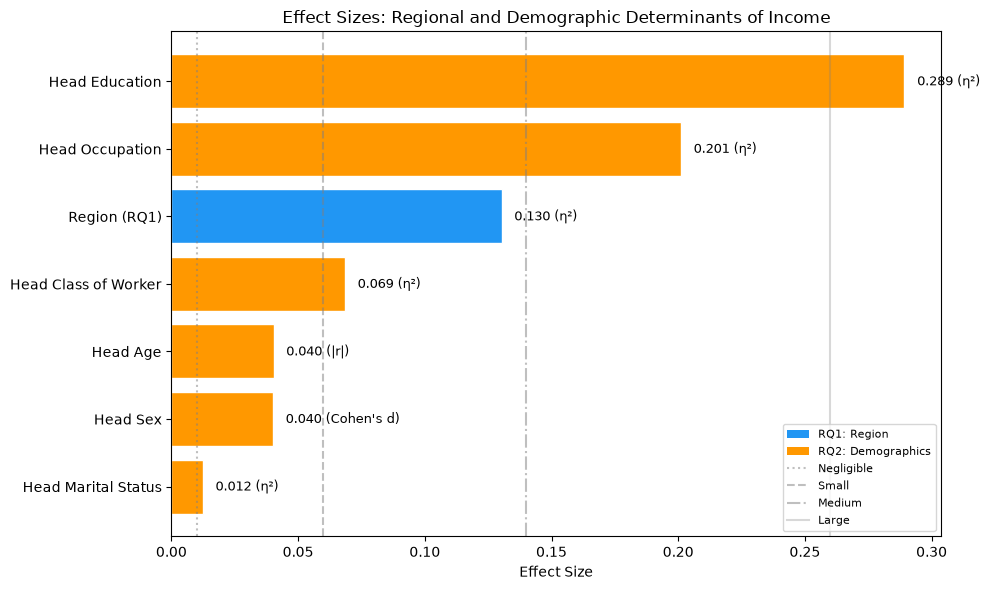

In [3]:
# Consolidated effect sizes for RQ1 and RQ2
effect_sizes = pd.DataFrame({
    "Variable": [
        "Region (RQ1)",
        "Head Education", "Head Occupation", "Head Class of Worker",
        "Head Age", "Head Sex", "Head Marital Status",
    ],
    "Effect Size": [0.1303, 0.2893, 0.2011, 0.0685, 0.0403, 0.0401, 0.0124],
    "Metric": ["η²", "η²", "η²", "η²", "|r|", "Cohen's d", "η²"],
    "RQ": ["RQ1", "RQ2", "RQ2", "RQ2", "RQ2", "RQ2", "RQ2"],
}).sort_values("Effect Size", ascending=True)

# Interpretation thresholds for η²
thresholds = {"negligible": 0.01, "small": 0.06, "medium": 0.14, "large": 0.26}

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2196F3" if r == "RQ1" else "#FF9800" for r in effect_sizes["RQ"]]

bars = ax.barh(effect_sizes["Variable"], effect_sizes["Effect Size"], color=colors, edgecolor="white")

# Add value labels
for bar, val, metric in zip(bars, effect_sizes["Effect Size"], effect_sizes["Metric"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f} ({metric})", va="center", fontsize=9)

# Reference lines
ax.axvline(0.01, color="gray", ls=":", alpha=0.5, label="Negligible (0.01)")
ax.axvline(0.06, color="gray", ls="--", alpha=0.5, label="Small (0.06)")
ax.axvline(0.14, color="gray", ls="-.", alpha=0.5, label="Medium (0.14)")
ax.axvline(0.26, color="gray", ls="-", alpha=0.3, label="Large (0.26)")

ax.set_xlabel("Effect Size")
ax.set_title("Effect Sizes: Regional and Demographic Determinants of Income")
ax.legend(loc="lower right", fontsize=8)

# Custom legend for RQ
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="RQ1: Region"),
    Patch(facecolor="#FF9800", label="RQ2: Demographics"),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color="gray", ls=":", alpha=0.5, label="Negligible"),
    plt.Line2D([0], [0], color="gray", ls="--", alpha=0.5, label="Small"),
    plt.Line2D([0], [0], color="gray", ls="-.", alpha=0.5, label="Medium"),
    plt.Line2D([0], [0], color="gray", ls="-", alpha=0.3, label="Large"),
], loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "23_rq_effect_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

Education (η² = 0.289) and occupation (η² = 0.201) are the only "large" effect
sizes. Region alone (η² = 0.130) falls in the medium-to-large range. Class of
worker is medium. Sex, age, and marital status are small — their bivariate
associations may largely reflect confounding with education and occupation.

---

## 5. RQ3: Predictive Regression Model

### RQ3 Results

We fit two OLS regression models:
- **Model 1:** Main effects only (region, education, occupation, class of worker,
  sex, marital status, age, family size, employed members)
- **Model 2:** Adds Region × Education interaction

| Metric | Model 1 | Model 2 |
|--------|---------|---------|
| R² | 0.4928 | **0.5006** |
| Adjusted R² | 0.4923 | **0.4999** |
| Parameters | 44 | 60 |
| AIC | 68,181 | 67,831 |
| BIC | 68,561 | 68,558 |

**Nested F-test:** F = 40.78, p ≈ 0 → interaction terms are jointly significant.
**Preferred model: Model 2.**

**Assumption checks:**
- Linearity: OK (LOWESS line near zero)
- Normality: OK (Shapiro-Wilk W = 0.993)
- Homoscedasticity: **Rejected** (Breusch-Pagan p ≈ 0) → HC1 robust SEs applied
- Multicollinearity: VIF range 2.7–7.6 (moderate, acceptable)

### 5.1 Model Comparison

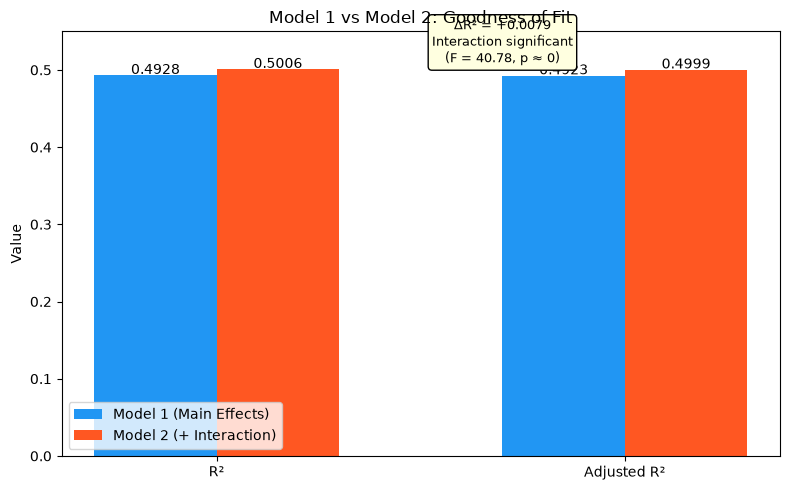

In [4]:
# Model comparison visualization
metrics = ["R²", "Adjusted R²"]
model1_vals = [0.4928, 0.4923]
model2_vals = [0.5006, 0.4999]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, model1_vals, width, label="Model 1 (Main Effects)", color="#2196F3")
bars2 = ax.bar(x + width/2, model2_vals, width, label="Model 2 (+ Interaction)", color="#FF5722")

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.4f}", ha="center", fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.4f}", ha="center", fontsize=10)

ax.set_ylabel("Value")
ax.set_title("Model 1 vs Model 2: Goodness of Fit")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 0.55)

# Add annotation
ax.annotate("ΔR² = +0.0079\nInteraction significant\n(F = 40.78, p ≈ 0)",
            xy=(0.7, 0.51), fontsize=9, ha="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

plt.tight_layout()
plt.savefig(FIG_DIR / "26_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Top Predictors by Standardized Coefficient

Standardized coefficients (beta weights) put all predictors on the same scale,
allowing direct comparison of predictor importance.

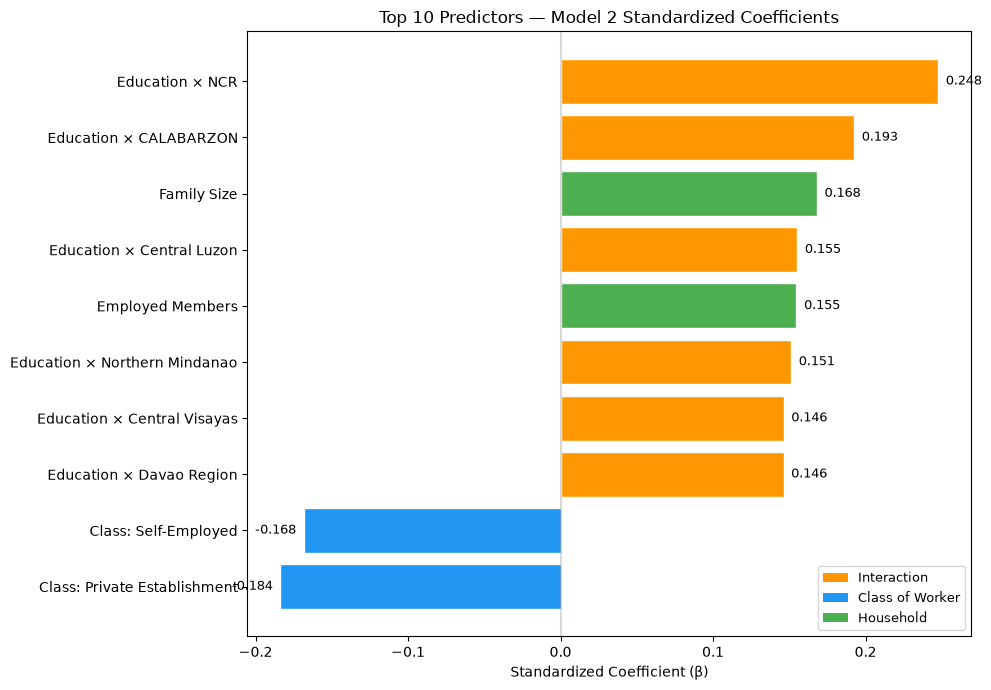

In [5]:
# Top predictors from Model 2 (standardized)
top_predictors = pd.DataFrame({
    "Predictor": [
        "Education × NCR",
        "Education × CALABARZON",
        "Class: Private Establishment",
        "Class: Self-Employed",
        "Family Size",
        "Education × Central Luzon",
        "Employed Members",
        "Education × Northern Mindanao",
        "Education × Central Visayas",
        "Education × Davao Region",
    ],
    "Standardized Coef": [0.2476, 0.1925, -0.1837, -0.1684, 0.1681, 0.1552, 0.1547, 0.1512, 0.1463, 0.1462],
    "Category": ["Interaction", "Interaction", "Class of Worker", "Class of Worker",
                  "Household", "Interaction", "Household", "Interaction", "Interaction", "Interaction"],
}).sort_values("Standardized Coef")

cat_colors = {
    "Interaction": "#FF9800",
    "Class of Worker": "#2196F3",
    "Household": "#4CAF50",
}
colors = [cat_colors[c] for c in top_predictors["Category"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_predictors["Predictor"], top_predictors["Standardized Coef"], color=colors, edgecolor="white")

for bar, val in zip(bars, top_predictors["Standardized Coef"]):
    offset = 0.005 if val >= 0 else -0.005
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha=ha, fontsize=9)

ax.axvline(0, color="gray", ls="-", alpha=0.3)
ax.set_xlabel("Standardized Coefficient (β)")
ax.set_title("Top 10 Predictors — Model 2 Standardized Coefficients")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in cat_colors.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "24_predictor_importance.png", dpi=150, bbox_inches="tight")
plt.show()

The education × region interaction terms dominate the predictor ranking. This means
the education premium is not uniform — it varies substantially by geography. The
positive coefficients for NCR, CALABARZON, and Central Luzon indicate that education
yields the highest returns in these urban/industrial regions.

**Class of worker** effects are negative (relative to the dropped reference category
"Employer in own family-operated farm or business"), meaning self-employed and
private-establishment workers earn less than employers — consistent with the
entrepreneurship premium.

---

## 6. Cross-RQ Synthesis

The three research questions build on each other:

**From RQ1 → RQ3:** Region is a significant predictor of income (η² = 0.130),
but its effect is partly absorbed by education and occupation in the multivariate
model. The raw NCR income premium shrinks once we control for the fact that NCR
has more college-educated, white-collar workers.

**From RQ2 → RQ3:** Education emerges as the strongest predictor in both bivariate
(η² = 0.289) and multivariate (largest standardized coefficient) analyses. However,
the regression reveals that education's effect is **not uniform across regions** —
the interaction term adds 0.8% to R² and is jointly significant.

**Key insight:** Income inequality in the Philippines is driven by a combination of
geographic and human capital factors, but the two are intertwined. A college degree
in NCR is worth more than the same degree in ARMM — suggesting that returns to
education depend on local labor market conditions.

---

## 7. Key Determinants Ranking

Combining evidence from all three RQs, we rank the strongest determinants of
household income:

In [6]:
# Consolidated ranking
ranking = pd.DataFrame({
    "Rank": [1, 2, 3, 4, 5, 6, 7, 8],
    "Determinant": [
        "Education (level)",
        "Region",
        "Occupation",
        "Class of Worker",
        "Education × Region interaction",
        "Family composition",
        "Sex of household head",
        "Age of household head",
    ],
    "Evidence": [
        "RQ2: η²=0.289 (large); RQ3: significant standardized coef",
        "RQ1: η²=0.130 (medium-large); RQ3: multiple region dummies significant",
        "RQ2: η²=0.201 (large); RQ3: occupation dummies significant",
        "RQ2: η²=0.069 (medium); RQ3: largest negative main effects",
        "RQ3: F=40.78, p≈0; education premium varies by geography",
        "RQ3: family size and employed members both significant",
        "RQ2: d=0.040 (small); RQ3: coeff=-0.062 (small negative)",
        "RQ2: r=0.040 (small); RQ3: coeff=+0.006 (near zero)",
    ],
    "Strength": ["Strong", "Strong", "Strong", "Moderate", "Moderate", "Moderate", "Weak", "Weak"],
})

print("=" * 80)
print("CONSOLIDATED DETERMINANT RANKING")
print("=" * 80)
for _, row in ranking.iterrows():
    print(f"\n  #{row['Rank']} {row['Determinant']} [{row['Strength']}]")
    print(f"     {row['Evidence']}")

CONSOLIDATED DETERMINANT RANKING

  #1 Education (level) [Strong]
     RQ2: η²=0.289 (large); RQ3: significant standardized coef

  #2 Region [Strong]
     RQ1: η²=0.130 (medium-large); RQ3: multiple region dummies significant

  #3 Occupation [Strong]
     RQ2: η²=0.201 (large); RQ3: occupation dummies significant

  #4 Class of Worker [Moderate]
     RQ2: η²=0.069 (medium); RQ3: largest negative main effects

  #5 Education × Region interaction [Moderate]
     RQ3: F=40.78, p≈0; education premium varies by geography

  #6 Family composition [Moderate]
     RQ3: family size and employed members both significant

  #7 Sex of household head [Weak]
     RQ2: d=0.040 (small); RQ3: coeff=-0.062 (small negative)

  #8 Age of household head [Weak]
     RQ2: r=0.040 (small); RQ3: coeff=+0.006 (near zero)


---

## 8. Policy Implications

### Education Investment
Education is the single strongest predictor of household income. Policies that
increase educational attainment — particularly completing high school and college —
would have the largest impact on household income.

### Regional Targeting
The education × region interaction means that education investments in low-return
regions (e.g., ARMM, Eastern Visayas) yield smaller income gains than the same
investments in high-return regions (NCR, CALABARZON). This does **not** mean
low-return regions should receive less — rather, education alone is insufficient
without complementary economic development to create demand for skilled labor.

### Formalization of Informal Work
Class of worker effects are substantial: self-employed and private-establishment
workers earn 36–39% less than employers (reference category). Policies supporting
entrepreneurship and formalization could reduce this gap.

### Addressing the Urban-Rural Divide
NCR households earn ~60% more than ARMM households. Bridging this gap requires
infrastructure investment, economic decentralization, and targeted regional
development programs.

---

## 9. Limitations & Future Work

### Limitations

1. **Endogeneity:** Occupation and class of worker may be simultaneously determined
   with income (simultaneity bias). OLS estimates are not causal.
2. **Omitted variables:** Ability, family background, social capital, and
   micro-level location are not captured in the FIES.
3. **Cross-sectional data:** Cannot establish temporal precedence or causal
   direction. We observe that education is associated with higher income, but
   cannot rule out that higher-income families invest more in education.
4. **R² ceiling:** The model explains ~50% of variance. The remaining 50% reflects
   individual variation, luck, unobserved factors, and measurement error.
5. **Ecological fallacy:** Regional-level effects may not apply to individuals
   within regions.

### Future Work

1. **Panel data:** Track the same households over time to establish temporal
   precedence and control for unobserved heterogeneity.
2. **Instrumental variables:** Use exogenous variation (e.g., distance to nearest
   school, policy changes) to address endogeneity.
3. **Multilevel modeling:** Model individuals nested within regions, regions nested
   within provinces, to properly partition variance.
4. **Machine learning:** Use gradient boosting or random forests to capture
   non-linear effects and higher-order interactions.
5. **Expenditure analysis:** Extend the model to predict expenditure patterns,
   not just income.